<a href="https://colab.research.google.com/github/kajalgupta19-web/data_analysis_projects/blob/main/Hotstart_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd # data manipulation
import matplotlib.pyplot as plt #data visualization
import seaborn as sns #data visualization

In [ ]:
df = pd.read_csv('hotstar.csv') #load data in variable df

In [ ]:
df.head()


,hotstar_id,title,description,genre,year,age_rating,running_time,seasons,episodes,type
0,1000087439,Sambha - Aajcha Chawa,A young man sets off on a mission to clean up ...,Action,2012,U/A 16+,141.0,NaN,NaN,movie
1,1260023113,Cars Toon: Mater And The Ghostlight,Mater is haunted by a mysterious blue light th...,Animation,2006,U,7.0,NaN,NaN,movie
2,1260103188,Kanmani Rambo Khatija,"Unlucky since birth, Rambo finds hope when he ...",Romance,2022,U/A 16+,157.0,NaN,NaN,movie
3,1260126754,Butterfly,While trying to rescue her sister's kids from ...,Thriller,2022,U/A 16+,136.0,NaN,NaN,movie
4,1260018228,Sister Act,"Rene, a lounge singer, decides to stay at a Ch...",Comedy,1992,U/A 7+,100.0,NaN,NaN,movie


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6874 entries, 0 to 6873
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hotstar_id    6874 non-null   int64  
 1   title         6874 non-null   object 
 2   description   6874 non-null   object 
 3   genre         6874 non-null   object 
 4   year          6874 non-null   int64  
 5   age_rating    6874 non-null   object 
 6   running_time  4568 non-null   float64
 7   seasons       2306 non-null   float64
 8   episodes      2306 non-null   float64
 9   type          6874 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 537.2+ KB


In [ ]:
df.describe()

,hotstar_id,year,running_time,seasons,episodes
count,6.874000e+03,6874.000000,4568.000000,2306.000000,2306.000000
mean,1.059077e+09,2011.718650,98.746716,2.661752,127.366869
std,4.812666e+08,11.936894,49.411142,4.942716,258.138186
min,3.000000e+00,1928.000000,1.000000,1.000000,1.000000
25%,1.000088e+09,2009.000000,70.000000,1.000000,6.000000
50%,1.260008e+09,2016.000000,116.000000,1.000000,22.000000
75%,1.260099e+09,2019.000000,135.000000,2.000000,130.750000
max,1.837059e+09,2023.000000,229.000000,73.000000,3973.000000


In [ ]:
#null values
df.isnull().sum()

,0
hotstar_id,0
title,0
description,0
genre,0
year,0
age_rating,0
running_time,2306
seasons,4568
episodes,4568
type,0


In [ ]:
# only running time , seasons, episodes have null values

In [ ]:
df['running_time'] = df['running_time'].fillna(df['running_time'].median())


In [ ]:
df['seasons'] = df['seasons'].fillna(df['seasons'].median())
df['episodes'] = df['episodes'].fillna(df['episodes'].median())

In [ ]:
#duplicates
df.duplicated().sum()

np.int64(0)

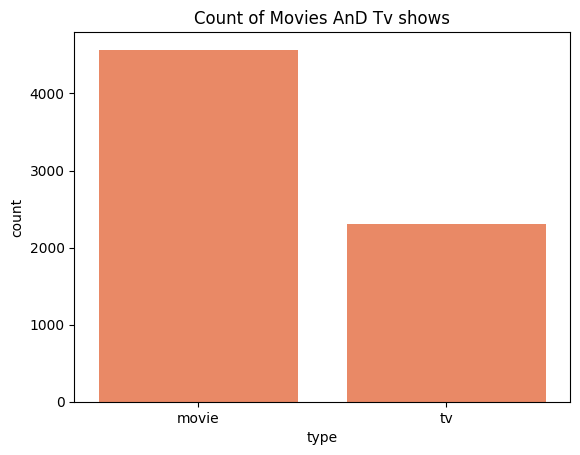

In [ ]:
#visualize count of tv shows and movies
sns.countplot(x=df['type'],data=df, color ='coral')
plt.title('Count of Movies AnD Tv shows')
plt.show()

In [ ]:
gb = df.groupby("type").agg({"hotstar_id":"count"})
gb

,hotstar_id
type,
movie,4568
tv,2306


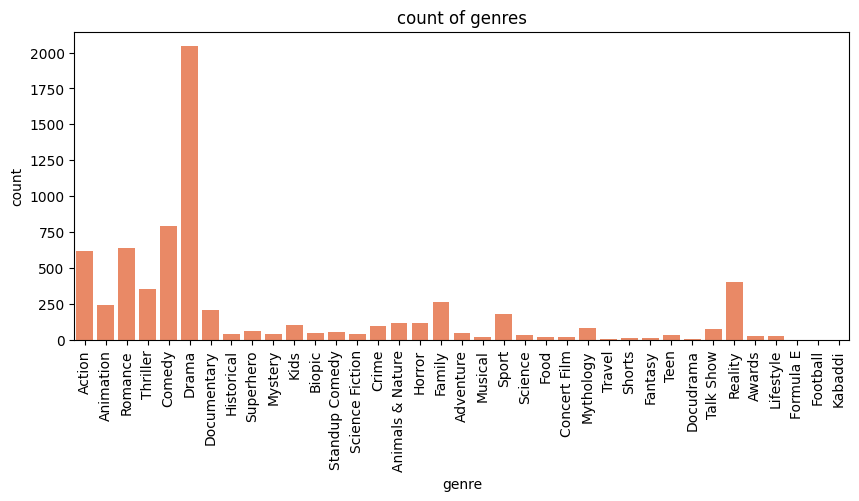

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(x=df['genre'],data=df, color ='coral')
plt.title('count of genres')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
gb = df.groupby("age_rating").agg({"hotstar_id":"count"})
gb

,hotstar_id
age_rating,
A,338
PG,1
U,1251
U/A 13+,2980
U/A 16+,1235
U/A 7+,1069


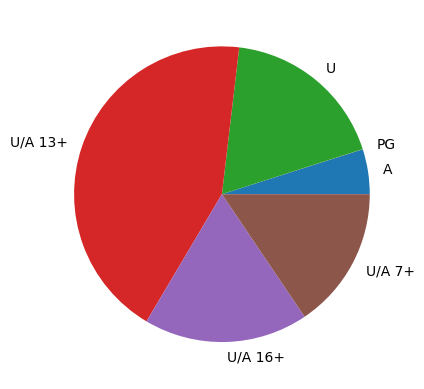

In [ ]:
plt.pie(gb['hotstar_id'],labels = gb.index)
plt.show()

In [ ]:

gb = df.groupby("year").agg({"hotstar_id":"count"})
gb

,hotstar_id
year,
1928,1
1937,1
1940,2
1941,5
1942,1
...,...
2019,498
2020,415
2021,561


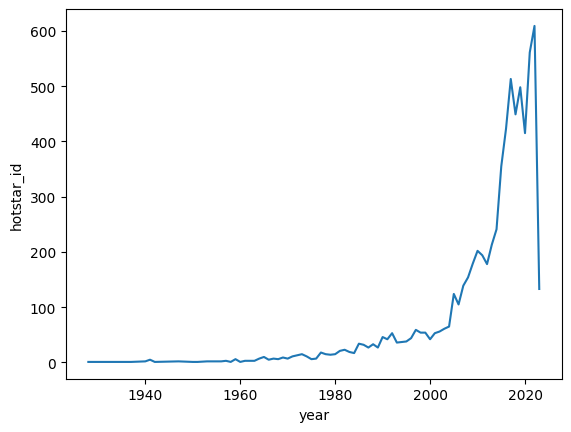

In [ ]:
sns.lineplot(x = gb.index, y = gb["hotstar_id"],markers='*')
plt.show()